### Packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm


In [3]:
claims_pivot = pd.read_csv("claims_pivot.csv")
codes_df = pd.read_excel("Codes Manual.xlsx")


In [4]:
claims_pivot = pd.read_csv(
    "claims_pivot.csv",
    index_col=0,
    parse_dates=[0]
)

claims_pivot.index.name = "CLAIM_FROM_MONTH"

In [5]:
claims_pivot

,0295T,0296T,0297T,0298T,0464T,11100,11101,11102,11103,11104,...,96127,96130,96131,96132,96133,96136,96137,96138,96139,96146
CLAIM_FROM_MONTH,,,,,,,,,,,,,,,,,,,,,
2018-01-01,NaN,45.0,566.0,88.0,NaN,10190.0,1047.0,NaN,NaN,NaN,...,146929.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02-01,NaN,108.0,705.0,192.0,NaN,9802.0,1176.0,NaN,NaN,NaN,...,139342.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01,14.0,112.0,908.0,276.0,NaN,11276.0,1254.0,NaN,NaN,NaN,...,160875.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-04-01,15.0,106.0,889.0,191.0,NaN,11231.0,1243.0,NaN,NaN,NaN,...,162667.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-05-01,14.0,188.0,1048.0,183.0,NaN,12689.0,1431.0,NaN,NaN,NaN,...,170539.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15312.0,1461.0,1334.0,...,691308.0,23027.0,13916.0,8487.0,4856.0,18435.0,12566.0,12158.0,4618.0,261.0
2023-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11959.0,1274.0,1099.0,...,513792.0,28620.0,13828.0,7437.0,4316.0,16344.0,11384.0,9961.0,3769.0,300.0
2023-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13886.0,1294.0,1225.0,...,525082.0,35483.0,16635.0,8489.0,4794.0,17984.0,12280.0,10317.0,4214.0,449.0


### Aggregates

In [6]:
# helper: sum listed code columns, treating missing columns as 0
def agg_codes(df, codes):
    return df.reindex(columns=codes, fill_value=0).fillna(0).sum(axis=1)

agg_map = {
    "Agg_autonomic_testing": ["95921", "95922", "95923", "95924"],
    "Agg_skin_biopsy": ["11100", "11101", "11102", "11103", "11104", "11105", "11106", "11107"],
    "Agg_cardiac_monitoring": ["0295T", "0296T", "0297T", "0298T", "93241", "93242", "93243", "93244", "93245", "93246", "93247", "93248"],
    "Agg_fractures": ["23500", "23600", "25600", "27500", "27750", "27786", "28470", "21310", "28510", "25605", "24670", "27236", "24546", "25606", "27235"],
    "Agg_nerve_conduction": ["95907", "95908", "95909", "95910", "95911", "95912", "95913"],
    "Agg_neurophysiologic/autonomic testing": ["95943", "95999"],
    "Agg_immunohistochemistry_stains": ["88341", "88342"],
    "Agg_psychological_testing": ["96130", "96131", "96132", "96133", "96134", "96135", "96136", "96137", "96138", "96139", "96146"],
    "Agg_neurobehavioral": ["96116", "96121"],
    "Agg_needle_EMG": ["95886", "95887"],
    "Agg_clotting":["85240", "85241", "85242", "85243", "85244", "85245", "85246", "85247", "85248", "85249", "85250", "85251", "85252", "85253", "85254", "85255", "85256", "85257", "85258", "85259", "85260", "85261", "85262", "85263", "85264", "85265", "85266", "85267", "85268", "85269", "85270"],
    "Agg_pregnancy_test": ["81025", "84073"],
    "Agg_fluorescent_noninfectious_agent": ["86383", "86051", "86052", "86053", "86255", "86256"],

}

for new_col, codes in agg_map.items():
    claims_pivot[new_col] = agg_codes(claims_pivot, codes)


/var/folders/dj/z48f7b2j74j0qb_5_slvd9w80000gn/T/ipykernel_5889/3691230814.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  claims_pivot[new_col] = agg_codes(claims_pivot, codes)
/var/folders/dj/z48f7b2j74j0qb_5_slvd9w80000gn/T/ipykernel_5889/3691230814.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  claims_pivot[new_col] = agg_codes(claims_pivot, codes)
/var/folders/dj/z48f7b2j74j0qb_5_slvd9w80000gn/T/ipykernel_5889/3691230814.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of cal

In [7]:
#robust toggle:
robust = True

non_robust = claims_pivot.copy()
#drop mach-may 2020
if robust:
    claims_pivot = claims_pivot[~claims_pivot.index.isin(pd.date_range("2020-03-01", "2020-05-31"))]


### ITS

$Y_tâ€‹=B_0â€‹+B_1â€‹T+B_2â€‹X_tâ€‹+B_3â€‹(X_tâ€‹â‹…T)$

In [8]:
code = "85379"
intervention_month = pd.Timestamp("2021-03-01")

ts = claims_pivot[[code]].reset_index()
ts.columns = ["month", "y"]

# start at first non-zero month so leading missing months are excluded
nonzero_idx = ts.index[ts["y"].fillna(0) > 0]
if len(nonzero_idx) > 0:
    ts = ts.loc[nonzero_idx[0]:].reset_index(drop=True)

ts["y"] = ts["y"].fillna(0)

# calendar-month index (preserves real time gaps if months are dropped)
ts["_month_index"] = ts["month"].dt.year * 12 + ts["month"].dt.month
ts["T"] = ts["_month_index"] - ts["_month_index"].iloc[0]

# intervention dummy
intervention_month = pd.Timestamp(intervention_month)
ts["X_t"] = (ts["month"] >= intervention_month).astype(int)

# calendar months since intervention (1 in intervention month)
intervention_month_index = intervention_month.year * 12 + intervention_month.month
ts["T'"] = 0
post_mask = ts["month"] >= intervention_month
if post_mask.any():
    ts.loc[post_mask, "T'"] = ts.loc[post_mask, "_month_index"] - intervention_month_index + 1

ts.head(50)

,month,y,_month_index,T,X_t,T'
0,2018-01-01,42337.0,24217,0,0,0
1,2018-02-01,37551.0,24218,1,0,0
2,2018-03-01,43575.0,24219,2,0,0
3,2018-04-01,42156.0,24220,3,0,0
4,2018-05-01,44378.0,24221,4,0,0
5,2018-06-01,39783.0,24222,5,0,0
6,2018-07-01,41413.0,24223,6,0,0
7,2018-08-01,42111.0,24224,7,0,0
8,2018-09-01,39238.0,24225,8,0,0
9,2018-10-01,40888.0,24226,9,0,0


In [9]:
X = sm.add_constant(ts[["T", "X_t", "T'"]])
y = ts["y"]

model = sm.GLM(y, X, family=sm.families.Poisson()).fit()
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   69
Model:                            GLM   Df Residuals:                       65
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -31718.
Date:                Mon, 06 Jul 2026   Deviance:                       62549.
Time:                        17:49:27   Pearson chi2:                 6.43e+04
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.4514      0.002   6800.379      0.0

In [10]:
X

,const,T,X_t,T'
0,1.0,0,0,0
1,1.0,1,0,0
2,1.0,2,0,0
3,1.0,3,0,0
4,1.0,4,0,0
...,...,...,...,...
64,1.0,67,1,30
65,1.0,68,1,31
66,1.0,69,1,32
67,1.0,70,1,33


In [11]:
def _trim_to_first_nonzero(ts):
    ts = ts.copy()
    ts["month"] = pd.to_datetime(ts["month"])
    ts["y"] = pd.to_numeric(ts["y"], errors="coerce")

    nonzero_idx = ts.index[ts["y"].fillna(0) > 0]
    if len(nonzero_idx) == 0:
        return ts.iloc[0:0].copy()

    start_idx = nonzero_idx[0]
    return ts.loc[start_idx:].reset_index(drop=True)


def fit_its_single(ts, intervention_month):
    ts = _trim_to_first_nonzero(ts)
    if ts.empty:
        raise ValueError("Series has no non-zero observations after trimming leading months.")

    # outcome
    ts["y"] = ts["y"].fillna(0)

    # calendar-month index (preserves real time gaps if months are dropped)
    ts["_month_index"] = ts["month"].dt.year * 12 + ts["month"].dt.month
    ts["T"] = ts["_month_index"] - ts["_month_index"].iloc[0]

    # intervention indicator
    intervention_month = pd.Timestamp(intervention_month)
    ts["X_t"] = (ts["month"] >= intervention_month).astype(int)

    # calendar months since intervention (1 in intervention month)
    intervention_month_index = intervention_month.year * 12 + intervention_month.month
    ts["post_time"] = 0
    post_mask = ts["month"] >= intervention_month
    if post_mask.any():
        ts.loc[post_mask, "post_time"] = ts.loc[post_mask, "_month_index"] - intervention_month_index + 1

    # design matrix
    X = sm.add_constant(ts[["T", "X_t", "post_time"]])
    y = ts["y"]

    # fit model
    model = sm.GLM(y, X, family=sm.families.Poisson()).fit()

    return model

In [12]:
results = []

intervention_month = pd.Timestamp("2021-03-01")

# Build metadata lookup once
meta_lookup = (
    codes_df.assign(CODE=codes_df["CODE"].astype(str).str.strip())
    .drop_duplicates(subset=["CODE"])
    .set_index("CODE")[["Description"]]
    .to_dict(orient="index")
)

for code in claims_pivot.columns:

    # build time series
    ts = claims_pivot[[code]].reset_index()
    ts.columns = ["month", "y"]
    ts = _trim_to_first_nonzero(ts)

    # skip sparse series
    observed = int(ts["y"].notna().sum())
    if observed < 37:
        print(f"Skipping code {code} due to insufficient data (observed {observed} months)")
        continue

    # get metadata
    code_str = str(code).strip()
    meta = meta_lookup.get(code_str, {})
    desc = meta.get("Description")

    try:
        model = fit_its_single(ts, intervention_month)

        params = model.params
        pvals = model.pvalues
        conf = model.conf_int()

        results.append({
            "HCPCS_CODE": code_str,
            "Description": desc,

            "B0_const": params.get("const", np.nan),
            "B1_time": params.get("T", np.nan),
            "B2_level": params.get("X_t", np.nan),
            "B3_slope": params.get("post_time", np.nan),

            "p_const": pvals.get("const", np.nan),
            "p_time": pvals.get("T", np.nan),
            "p_level": pvals.get("X_t", np.nan),
            "p_slope": pvals.get("post_time", np.nan),

            "ci_const_low": conf.loc["const", 0] if "const" in conf.index else np.nan,
            "ci_const_high": conf.loc["const", 1] if "const" in conf.index else np.nan,

            "ci_time_low": conf.loc["T", 0] if "T" in conf.index else np.nan,
            "ci_time_high": conf.loc["T", 1] if "T" in conf.index else np.nan,

            "ci_level_low": conf.loc["X_t", 0] if "X_t" in conf.index else np.nan,
            "ci_level_high": conf.loc["X_t", 1] if "X_t" in conf.index else np.nan,

            "ci_slope_low": conf.loc["post_time", 0] if "post_time" in conf.index else np.nan,
            "ci_slope_high": conf.loc["post_time", 1] if "post_time" in conf.index else np.nan,

            "Deviance" : model.deviance,
            "N_obs": observed
        })

    except Exception as e:
        results.append({
            "HCPCS_CODE": code_str,
            "Description": desc,
            "ERROR": str(e)
        })


Skipping code 0295T due to insufficient data (observed 28 months)
Skipping code 0296T due to insufficient data (observed 33 months)
Skipping code 0297T due to insufficient data (observed 33 months)
Skipping code 0298T due to insufficient data (observed 33 months)
Skipping code 0464T due to insufficient data (observed 2 months)
Skipping code 11100 due to insufficient data (observed 13 months)
Skipping code 11101 due to insufficient data (observed 12 months)
Skipping code 21310 due to insufficient data (observed 18 months)
Skipping code 23600 due to insufficient data (observed 1 months)
Skipping code 27500 due to insufficient data (observed 10 months)
Skipping code 27750 due to insufficient data (observed 32 months)
Skipping code 28510 due to insufficient data (observed 33 months)
Skipping code 38505 due to insufficient data (observed 26 months)
Skipping code 38525 due to insufficient data (observed 8 months)
Skipping code 71271 due to insufficient data (observed 36 months)
Skipping code

In [13]:
results

[{'HCPCS_CODE': '11102',
  'Description': 'Tangential skin biopsy, single lesion',
  'B0_const': np.float64(9.012655498586401),
  'B1_time': np.float64(6.414198064149789e-05),
  'B2_level': np.float64(0.27931546058659174),
  'B3_slope': np.float64(0.0036032061624284815),
  'p_const': np.float64(0.0),
  'p_time': np.float64(0.8254556948520673),
  'p_level': np.float64(0.0),
  'p_slope': np.float64(2.869814942936818e-27),
  'ci_const_low': np.float64(9.004377262022476),
  'ci_const_high': np.float64(9.020933735150326),
  'ci_time_low': np.float64(-0.0005059119066393894),
  'ci_time_high': np.float64(0.0006341958679223852),
  'ci_level_low': np.float64(0.2685546095934334),
  'ci_level_high': np.float64(0.29007631157975006),
  'ci_slope_low': np.float64(0.0029503114258884943),
  'ci_slope_high': np.float64(0.004256100898968469),
  'Deviance': np.float64(14656.30727773906),
  'N_obs': 57},
 {'HCPCS_CODE': '11103',
  'Description': 'Tangential skin biopsy, each additional lesion',
  'B0_cons

In [14]:
results_df = pd.DataFrame(results)

# optional sorting
results_df = results_df.sort_values("p_level")

def smart_format(x):
    if pd.isna(x):
        return ""
    if isinstance(x, (int, np.integer)):
        return str(x)
    if isinstance(x, (float, np.floating)):
        if x == 0:
            return "0.0000"
        if abs(x) < 1e-4:
            return f"{x:.2E}"
        return f"{x:.4f}"
    return x

for col in results_df.columns:
    if pd.api.types.is_numeric_dtype(results_df[col]):
        results_df[col] = results_df[col].apply(smart_format)

#replace nan with 0
results_df = results_df.replace("nan", 0)
results_df = results_df.replace("", 0)
results_df

,HCPCS_CODE,Description,B0_const,B1_time,B2_level,B3_slope,p_const,p_time,p_level,p_slope,ci_const_low,ci_const_high,ci_time_low,ci_time_high,ci_level_low,ci_level_high,ci_slope_low,ci_slope_high,Deviance,N_obs
0,11102,"Tangential skin biopsy, single lesion",9.0127,6.41E-05,0.2793,0.0036,0.0000,0.8255,0.0000,2.87E-27,9.0044,9.0209,-0.0005,0.0006,0.2686,0.2901,0.0030,0.0043,14656.3073,57
183,Agg_pregnancy_test,NaN,13.1031,-0.0007,0.1141,0.0030,0.0000,4.51E-219,0.0000,0.0000,13.1022,13.1040,-0.0007,-0.0006,0.1128,0.1154,0.0029,0.0030,208219.8983,69
87,88342,Immunohistochemistry stains often used to visu...,10.6294,0.0095,0.1348,-0.0077,0.0000,0.0000,0.0000,0.0000,10.6264,10.6323,0.0093,0.0096,0.1309,0.1386,-0.0079,-0.0075,53506.7021,69
84,88305,"Surgical pathology, gross and microscopic exam...",12.7849,0.0029,0.1290,-0.0030,0.0000,0.0000,0.0000,0.0000,12.7838,12.7859,0.0028,0.0029,0.1275,0.1305,-0.0031,-0.0029,242548.9396,69
83,87338,H. pylori stool antigen,9.3038,0.0064,0.1753,-8.41E-05,0.0000,0.0000,0.0000,0.6537,9.2980,9.3096,0.0061,0.0067,0.1676,0.1831,-0.0005,0.0003,12120.5868,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13,29827,Arthroscopic shoulder rotator cuff repair,1.6347,0.0512,0.0488,-0.0878,2.78E-51,4.46E-35,0.6172,6.68E-52,1.4220,1.8474,0.0431,0.0593,-0.1425,0.2401,-0.0992,-0.0765,1629.8174,38
180,Agg_neurobehavioral,NaN,7.4450,0.0195,0.0038,-0.0172,0.0000,0.0000,0.6538,0.0000,7.4312,7.4588,0.0189,0.0201,-0.0128,0.0204,-0.0180,-0.0163,8154.4866,69
89,88356,Morphometric analysis for nerve density (speci...,7.0525,-0.0408,-0.0087,0.0330,0.0000,0.0000,0.7612,1.85E-131,7.0308,7.0743,-0.0421,-0.0394,-0.0649,0.0475,0.0303,0.0356,1036.7042,69
42,85244,Clotting factors (selective use),4.2588,0.0120,0.0070,0.0057,0.0000,1.07E-13,0.8782,0.0077,4.1886,4.3291,0.0088,0.0151,-0.0823,0.0963,0.0015,0.0099,373.1037,69


In [15]:
results_df.to_csv("its_results_poisson.csv", index=False)

### Plots

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   69
Model:                            GLM   Df Residuals:                       65
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1741.6
Date:                Mon, 06 Jul 2026   Deviance:                       3103.6
Time:                        17:49:32   Pearson chi2:                 2.89e+03
No. Iterations:                     7   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0420      0.011    664.004      0.0

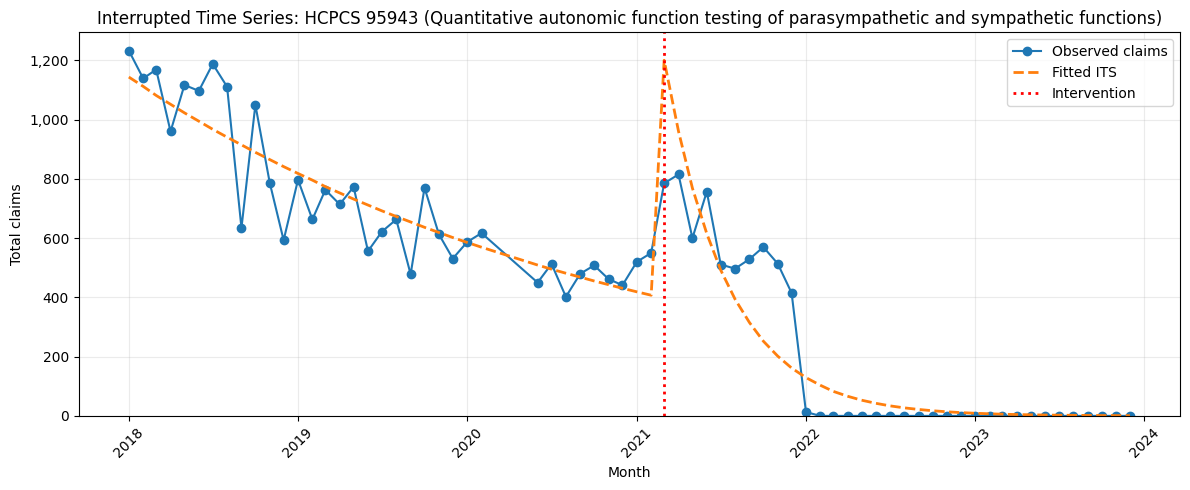

In [16]:
def plot_interrupted_time_series(claims_pivot, code, intervention_month, fill_missing=0, figsize=(12, 5)):
    code = str(code).strip()

    ts = claims_pivot[[code]].reset_index()
    ts.columns = ["month", "y"]
    ts = _trim_to_first_nonzero(ts)
    if ts.empty:
        raise ValueError(f"Series {code} has no non-zero observations after trimming leading months.")
    ts["y"] = ts["y"].fillna(fill_missing)

    # calendar-month index (preserves real time gaps if months are dropped)
    ts["_month_index"] = ts["month"].dt.year * 12 + ts["month"].dt.month
    ts["T"] = ts["_month_index"] - ts["_month_index"].iloc[0]

    # intervention dummy
    intervention_month = pd.Timestamp(intervention_month)
    ts["X_t"] = (ts["month"] >= intervention_month).astype(int)

    # calendar months since intervention (1 in intervention month)
    intervention_month_index = intervention_month.year * 12 + intervention_month.month
    ts["T'"] = 0
    post_mask = ts["month"] >= intervention_month
    if post_mask.any():
        ts.loc[post_mask, "T'"] = ts.loc[post_mask, "_month_index"] - intervention_month_index + 1

    X = sm.add_constant(ts[["T", "X_t", "T'"]])
    y = ts["y"]

    model = sm.GLM(y, X, family=sm.families.Poisson()).fit()
    ts["y_hat"] = model.predict(X)

    desc = None
    if "codes_df" in globals() and {"CODE", "Description"}.issubset(codes_df.columns):
        meta = codes_df.assign(CODE=codes_df["CODE"].astype(str).str.strip())
        match = meta.loc[meta["CODE"] == code, "Description"]
        if not match.empty:
            desc = match.iloc[0]

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(ts["month"], ts["y"], marker="o", linewidth=1.5, label="Observed claims")
    ax.plot(ts["month"], ts["y_hat"], linestyle="--", linewidth=2, label="Fitted ITS")
    ax.axvline(intervention_month, color="red", linestyle=":", linewidth=2, label="Intervention")
    ax.set_xlabel("Month")
    ax.set_ylabel("Total claims")
    y_max = float(np.nanmax(np.r_[ts["y"].to_numpy(dtype=float), ts["y_hat"].to_numpy(dtype=float), [0.0]]))
    ax.set_ylim(0, y_max * 1.05 if y_max > 0 else 1.0)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.2f}".rstrip("0").rstrip(".")))

    title = f"Interrupted Time Series: HCPCS {code}"
    if desc:
        title = f"{title} ({desc})"
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.25)
    plt.xticks(rotation=45)
    plt.tight_layout()

    return ts, model, fig, ax


# Example
ts, model, fig, ax = plot_interrupted_time_series(
    claims_pivot=claims_pivot,
    code="95943",
    intervention_month=pd.Timestamp("2021-03-01")
)

print(model.summary())

Normalization

104075749
93447612


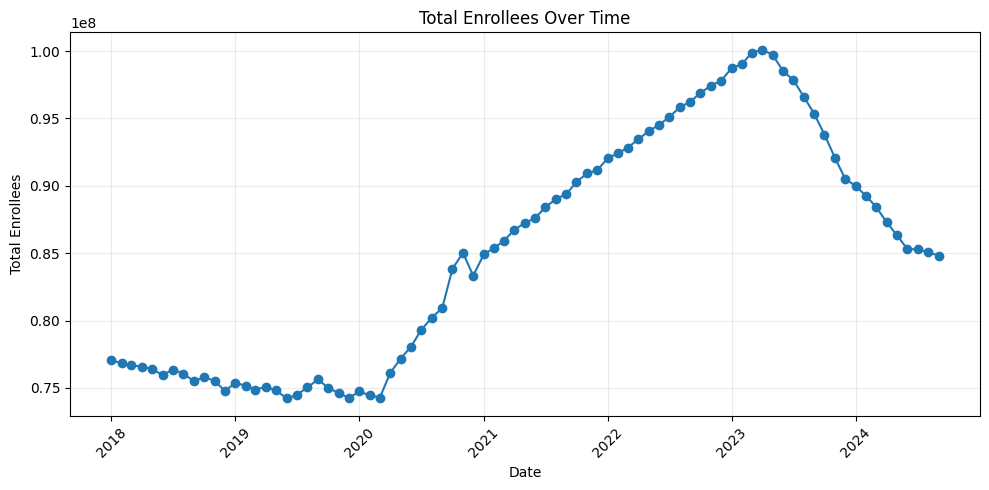

,Date,Total Enrollees
0,2018-01-01,77061511
1,2018-02-01,76816414
2,2018-03-01,76672124
3,2018-04-01,76587909
4,2018-05-01,76388516
...,...,...
76,2024-05-01,86344918
77,2024-06-01,85303813
78,2024-07-01,85289974
79,2024-08-01,85093798


In [19]:
#pull enrollement data from first sheet of excel file
enrollment = pd.read_excel("Enrollees_Merged.xlsx")
enrollment=enrollment[["Date", "Total Enrollees"]]

apr_2022 = enrollment[enrollment["Date"] == pd.Timestamp("2022-04-01")]["Total Enrollees"].iloc[0]
print(apr_2022)

mar_2022 = enrollment[enrollment["Date"] == pd.Timestamp("2022-03-01")]["Total Enrollees"].iloc[0]
may_2022 = enrollment[enrollment["Date"] == pd.Timestamp("2022-05-01")]["Total Enrollees"].iloc[0]
# set april 2022 to average of march and may
apr_2022 = (mar_2022 + may_2022) // 2

enrollment.loc[
    enrollment["Date"] == pd.Timestamp("2022-04-01"),
    "Total Enrollees"
] = apr_2022

print(apr_2022)

#plot enrollment over time
plt.figure(figsize=(10, 5))
plt.plot(enrollment["Date"], enrollment["Total Enrollees"], marker="o", linestyle="-")
plt.title("Total Enrollees Over Time")
plt.xlabel("Date")
plt.ylabel("Total Enrollees")
plt.xticks(rotation=45)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

enrollment

In [20]:
enrollment = enrollment.copy()
enrollment = enrollment.rename(
    columns={
        "Date": "month",
        "Total Enrollees": "enrollment"
    }
)

enrollment["month"] = pd.to_datetime(enrollment["month"]).dt.to_period("M").dt.to_timestamp()



Poisson

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   69
Model:                            GLM   Df Residuals:                       65
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8249.8
Date:                Mon, 06 Jul 2026   Deviance:                       15655.
Time:                        17:50:39   Pearson chi2:                 1.57e+04
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.0306      0.002  -4118.725      0.0

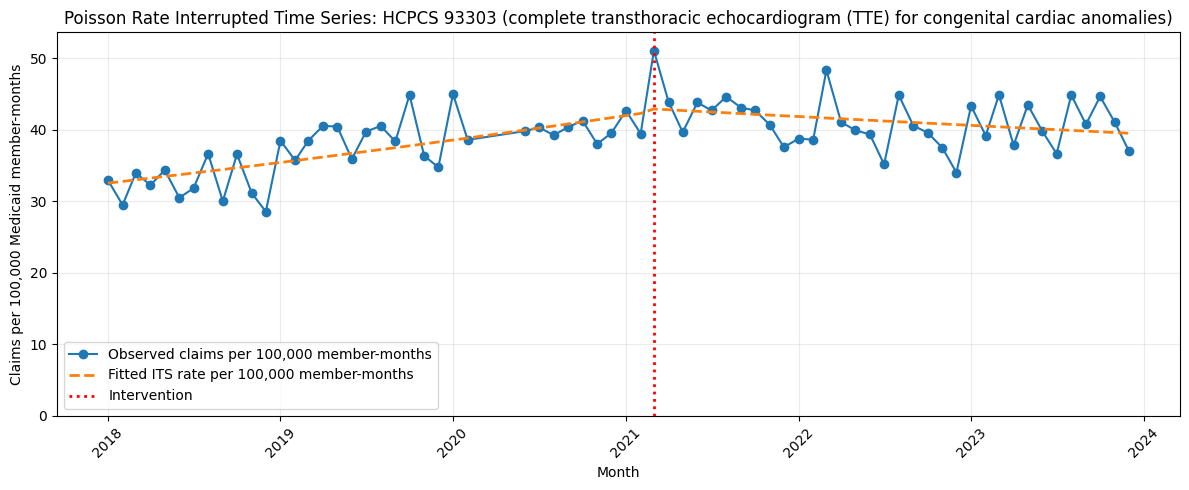

In [21]:
def plot_interrupted_time_series(
    claims_pivot,
    code,
    intervention_month,
    fill_missing=0,
    rate_multiplier=100000,
    figsize=(12, 5)
):
    code = str(code).strip()

    ts = claims_pivot[[code]].reset_index()
    ts.columns = ["month", "y"]

    # Ensure month alignment
    ts["month"] = pd.to_datetime(ts["month"]).dt.to_period("M").dt.to_timestamp()

    enrollment_clean = enrollment.copy()
    enrollment_clean["month"] = pd.to_datetime(
        enrollment_clean["month"]
    ).dt.to_period("M").dt.to_timestamp()

    ts = ts.merge(
        enrollment_clean[["month", "enrollment"]],
        on="month",
        how="left",
        validate="many_to_one"
    )

    ts = _trim_to_first_nonzero(ts)
    if ts.empty:
        raise ValueError(f"Series {code} has no non-zero observations after trimming leading months.")

    ts["y"] = ts["y"].fillna(fill_missing)

    if ts["enrollment"].isna().any():
        missing = ts.loc[ts["enrollment"].isna(), "month"].dt.strftime("%Y-%m").tolist()
        raise ValueError(f"Missing enrollment values for months: {missing}")

    if (ts["enrollment"] <= 0).any():
        bad = ts.loc[ts["enrollment"] <= 0, "month"].dt.strftime("%Y-%m").tolist()
        raise ValueError(f"Enrollment must be positive. Bad months: {bad}")

    # calendar-month index
    ts["_month_index"] = ts["month"].dt.year * 12 + ts["month"].dt.month
    ts["T"] = ts["_month_index"] - ts["_month_index"].iloc[0]

    # intervention dummy
    intervention_month = pd.Timestamp(intervention_month).to_period("M").to_timestamp()
    ts["X_t"] = (ts["month"] >= intervention_month).astype(int)

    # calendar months since intervention
    intervention_month_index = intervention_month.year * 12 + intervention_month.month
    ts["T'"] = 0
    post_mask = ts["month"] >= intervention_month
    if post_mask.any():
        ts.loc[post_mask, "T'"] = (
            ts.loc[post_mask, "_month_index"] - intervention_month_index + 1
        )

    X = sm.add_constant(ts[["T", "X_t", "T'"]])
    y = ts["y"]

    model = sm.GLM(
        y,
        X,
        family=sm.families.Poisson(),
        exposure=ts["enrollment"]
    ).fit()

    # Predicted counts
    ts["y_hat"] = model.predict(X, exposure=ts["enrollment"])

    # Convert observed and fitted counts to rates
    ts["rate"] = ts["y"] / ts["enrollment"] * rate_multiplier
    ts["rate_hat"] = ts["y_hat"] / ts["enrollment"] * rate_multiplier

    desc = None
    if "codes_df" in globals() and {"CODE", "Description"}.issubset(codes_df.columns):
        meta = codes_df.assign(CODE=codes_df["CODE"].astype(str).str.strip())
        match = meta.loc[meta["CODE"] == code, "Description"]
        if not match.empty:
            desc = match.iloc[0]

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        ts["month"],
        ts["rate"],
        marker="o",
        linewidth=1.5,
        label=f"Observed claims per {rate_multiplier:,} member-months"
    )

    ax.plot(
        ts["month"],
        ts["rate_hat"],
        linestyle="--",
        linewidth=2,
        label=f"Fitted ITS rate per {rate_multiplier:,} member-months"
    )

    ax.axvline(
        intervention_month,
        color="red",
        linestyle=":",
        linewidth=2,
        label="Intervention"
    )

    ax.set_xlabel("Month")
    ax.set_ylabel(f"Claims per {rate_multiplier:,} Medicaid member-months")

    y_max = float(
        np.nanmax(
            np.r_[
                ts["rate"].to_numpy(dtype=float),
                ts["rate_hat"].to_numpy(dtype=float),
                [0.0]
            ]
        )
    )

    ax.set_ylim(0, y_max * 1.05 if y_max > 0 else 1.0)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda x, _: f"{x:,.2f}".rstrip("0").rstrip("."))
    )

    title = f"Poisson Rate Interrupted Time Series: HCPCS {code}"
    if desc:
        title = f"{title} ({desc})"

    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.25)
    plt.xticks(rotation=45)
    plt.tight_layout()

    return ts, model, fig, ax


# Example
ts, model, fig, ax = plot_interrupted_time_series(
    claims_pivot=claims_pivot,
    code="93303",
    intervention_month=pd.Timestamp("2021-03-01")
)

print(model.summary())

Neg Binomial

                     NegativeBinomial Regression Results                      
Dep. Variable:                      y   No. Observations:                   69
Model:               NegativeBinomial   Df Residuals:                       65
Method:                           MLE   Df Model:                            3
Date:                Mon, 06 Jul 2026   Pseudo R-squ.:                  0.1516
Time:                        17:50:53   Log-Likelihood:                -362.92
converged:                       True   LL-Null:                       -427.78
Covariance Type:            nonrobust   LLR p-value:                 6.215e-28
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.1026      0.254    -43.744      0.000     -11.600     -10.605
T             -0.0288      0.012     -2.388      0.017      -0.052      -0.005
X_t            4.1538      0.723      5.749      0.0

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)


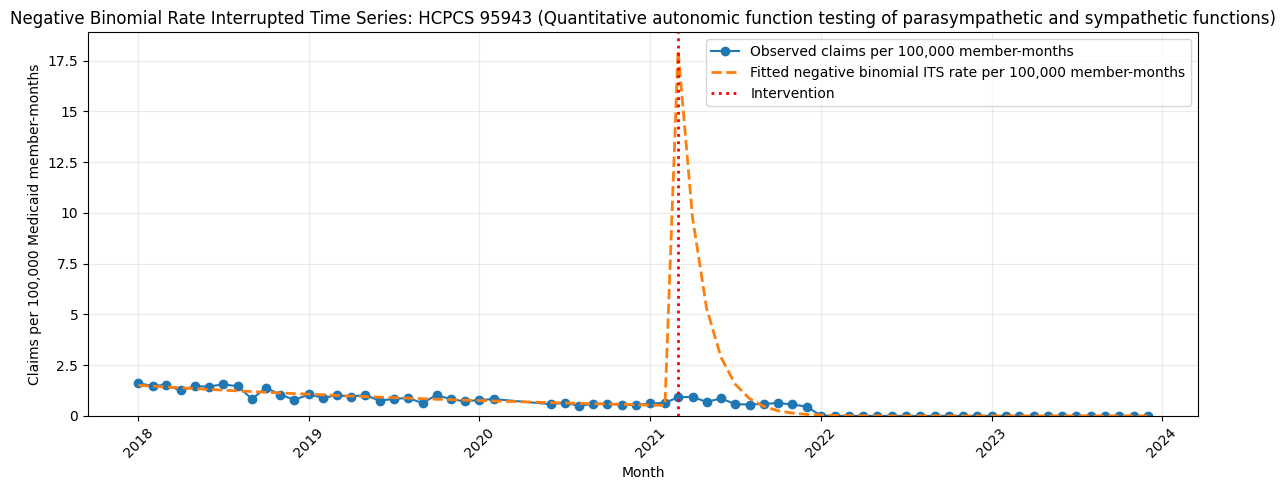

In [23]:
def plot_interrupted_time_series(
    claims_pivot,
    code,
    intervention_month,
    fill_missing=0,
    rate_multiplier=100000,
    figsize=(12, 5)
):
    code = str(code).strip()

    ts = claims_pivot[[code]].reset_index()
    ts.columns = ["month", "y"]

    # Ensure month alignment
    ts["month"] = pd.to_datetime(ts["month"]).dt.to_period("M").dt.to_timestamp()

    enrollment_clean = enrollment.copy()
    enrollment_clean["month"] = pd.to_datetime(
        enrollment_clean["month"]
    ).dt.to_period("M").dt.to_timestamp()

    ts = ts.merge(
        enrollment_clean[["month", "enrollment"]],
        on="month",
        how="left",
        validate="many_to_one"
    )

    ts = _trim_to_first_nonzero(ts)
    if ts.empty:
        raise ValueError(f"Series {code} has no non-zero observations after trimming leading months.")

    ts["y"] = ts["y"].fillna(fill_missing)

    if ts["enrollment"].isna().any():
        missing = ts.loc[ts["enrollment"].isna(), "month"].dt.strftime("%Y-%m").tolist()
        raise ValueError(f"Missing enrollment values for months: {missing}")

    if (ts["enrollment"] <= 0).any():
        bad = ts.loc[ts["enrollment"] <= 0, "month"].dt.strftime("%Y-%m").tolist()
        raise ValueError(f"Enrollment must be positive. Bad months: {bad}")

    # calendar-month index
    ts["_month_index"] = ts["month"].dt.year * 12 + ts["month"].dt.month
    ts["T"] = ts["_month_index"] - ts["_month_index"].iloc[0]

    # intervention dummy
    intervention_month = pd.Timestamp(intervention_month).to_period("M").to_timestamp()
    ts["X_t"] = (ts["month"] >= intervention_month).astype(int)

    # calendar months since intervention
    intervention_month_index = intervention_month.year * 12 + intervention_month.month
    ts["T'"] = 0
    post_mask = ts["month"] >= intervention_month
    if post_mask.any():
        ts.loc[post_mask, "T'"] = (
            ts.loc[post_mask, "_month_index"] - intervention_month_index + 1
        )

    X = sm.add_constant(ts[["T", "X_t", "T'"]])
    y = ts["y"]

    # Negative binomial rate model:
    # y is the count, enrollment is the exposure denominator.
    model = sm.NegativeBinomial(
        y,
        X,
        exposure=ts["enrollment"]
    ).fit(disp=False)

    # Predicted counts
    ts["y_hat"] = model.predict(X, exposure=ts["enrollment"])

    # Convert observed and fitted counts to rates
    ts["rate"] = ts["y"] / ts["enrollment"] * rate_multiplier
    ts["rate_hat"] = ts["y_hat"] / ts["enrollment"] * rate_multiplier

    desc = None
    if "codes_df" in globals() and {"CODE", "Description"}.issubset(codes_df.columns):
        meta = codes_df.assign(CODE=codes_df["CODE"].astype(str).str.strip())
        match = meta.loc[meta["CODE"] == code, "Description"]
        if not match.empty:
            desc = match.iloc[0]

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        ts["month"],
        ts["rate"],
        marker="o",
        linewidth=1.5,
        label=f"Observed claims per {rate_multiplier:,} member-months"
    )

    ax.plot(
        ts["month"],
        ts["rate_hat"],
        linestyle="--",
        linewidth=2,
        label=f"Fitted negative binomial ITS rate per {rate_multiplier:,} member-months"
    )

    ax.axvline(
        intervention_month,
        color="red",
        linestyle=":",
        linewidth=2,
        label="Intervention"
    )

    ax.set_xlabel("Month")
    ax.set_ylabel(f"Claims per {rate_multiplier:,} Medicaid member-months")

    y_max = float(
        np.nanmax(
            np.r_[
                ts["rate"].to_numpy(dtype=float),
                ts["rate_hat"].to_numpy(dtype=float),
                [0.0]
            ]
        )
    )

    ax.set_ylim(0, y_max * 1.05 if y_max > 0 else 1.0)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda x, _: f"{x:,.2f}".rstrip("0").rstrip("."))
    )

    title = f"Negative Binomial Rate Interrupted Time Series: HCPCS {code}"
    if desc:
        title = f"{title} ({desc})"

    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.25)
    plt.xticks(rotation=45)
    plt.tight_layout()

    return ts, model, fig, ax


ts, model, fig, ax = plot_interrupted_time_series(
    claims_pivot=claims_pivot,
    code="95943",
    intervention_month=pd.Timestamp("2021-03-01")
)

print(model.summary())

Build Normalized Poisson PowerPoint

In [90]:
import io
import re
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from matplotlib.ticker import FuncFormatter
from pptx import Presentation
from pptx.util import Pt

EMU_PER_PT = 12700


def _norm_text(value):
    text = str(value).strip().lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def _norm_agg_code(value):
    text = re.sub(r"(?i)^agg[_\s-]*", "", str(value).strip())
    return _norm_text(text)


def _ensure_aggregates_for_deck(df, agg_map):
    out = df.copy()
    lookup = {str(col).strip().upper(): col for col in out.columns}
    for agg_name, codes in (agg_map or {}).items():
        agg_col = str(agg_name).strip()
        present_cols = [lookup[str(code).strip().upper()] for code in codes if str(code).strip().upper() in lookup]
        out[agg_col] = out[present_cols].fillna(0).sum(axis=1) if present_cols else 0.0
    return out


def _aggregate_title_lookup(claims_df, agg_map):
    lookup = {}
    for agg_name in (agg_map or {}).keys():
        agg_col = str(agg_name).strip()
        title = "Aggregate " + _norm_agg_code(agg_col).title()
        lookup[_norm_text(title)] = agg_col
    for col in claims_df.columns:
        col_text = str(col).strip()
        if col_text.upper().startswith("AGG"):
            title = "Aggregate " + _norm_agg_code(col_text).title()
            lookup[_norm_text(title)] = col_text
    return lookup


def _slide_title(slide):
    try:
        if slide.shapes.title is not None and slide.shapes.title.text:
            return slide.shapes.title.text.strip()
    except Exception:
        pass
    for shape in slide.shapes:
        if getattr(shape, "has_text_frame", False) and shape.text and shape.text.strip():
            return shape.text.strip().splitlines()[0]
    return ""


def _slide_code(title, claims_df, agg_lookup):
    if title.lower().startswith("normalized its"):
        return None

    hcpcs = re.match(r"^\s*HCPCS\s+([A-Z0-9]+)\b", title, flags=re.IGNORECASE)
    if hcpcs:
        code = hcpcs.group(1).strip().upper()
        claims_lookup = {str(col).strip().upper(): str(col).strip() for col in claims_df.columns}
        return claims_lookup.get(code)

    aggregate = re.match(r"^\s*Aggregate\s+(.+?)\s*$", title, flags=re.IGNORECASE)
    if aggregate:
        key = _norm_text("Aggregate " + aggregate.group(1).strip())
        return agg_lookup.get(key)

    return None


def _extract_template_geometry(slide):
    geom = {
        "title_left": 177800,
        "title_top": 228600,
        "title_width": 11836400,
        "title_height": 461665,
        "plot_left": 896555,
        "plot_top": 1646674,
        "plot_width": 5395090,
        "plot_height": 4275853,
        "summary_left": 7137400,
        "summary_top": 889000,
        "summary_width": 4376198,
        "summary_height": 2954655,
    }

    text_shapes = [shape for shape in slide.shapes if getattr(shape, "has_text_frame", False)]
    pic_shapes = [shape for shape in slide.shapes if shape.shape_type == 13]

    if pic_shapes:
        pic = pic_shapes[0]
        geom.update({
            "plot_left": int(pic.left),
            "plot_top": int(pic.top),
            "plot_width": int(pic.width),
            "plot_height": int(pic.height),
        })

    if text_shapes:
        text_shapes = sorted(text_shapes, key=lambda shape: (int(shape.top), int(shape.left)))
        title_shape = text_shapes[0]
        geom.update({
            "title_left": int(title_shape.left),
            "title_top": int(title_shape.top),
            "title_width": int(title_shape.width),
            "title_height": int(title_shape.height),
        })

        summary_candidates = [
            shape for shape in text_shapes[1:] if int(shape.width) > 0 and int(shape.height) > 0
        ]
        if summary_candidates:
            summary_shape = max(summary_candidates, key=lambda shape: int(shape.width) * int(shape.height))
            geom.update({
                "summary_left": int(summary_shape.left),
                "summary_top": int(summary_shape.top),
                "summary_width": int(summary_shape.width),
                "summary_height": int(summary_shape.height),
            })

    return geom


def _build_ts_for_deck(claims_df, code_col):
    ts = claims_df[[code_col]].reset_index()
    ts.columns = ["month", "y"]
    ts["month"] = pd.to_datetime(ts["month"]).dt.to_period("M").dt.to_timestamp()
    ts["y"] = pd.to_numeric(ts["y"], errors="coerce")
    return _trim_to_first_nonzero(ts)


def _choose_series_for_deck(claims_full, claims_drop, code_col, observed_hint=None):
    full = _build_ts_for_deck(claims_full, code_col)
    dropped = _build_ts_for_deck(claims_drop, code_col)

    if observed_hint is not None:
        if int(dropped["y"].notna().sum()) == observed_hint:
            return dropped
        if int(full["y"].notna().sum()) == observed_hint:
            return full

    return dropped if full.empty and not dropped.empty else full


def _fit_normalized_poisson_for_deck(ts_raw, enrollment_df, intervention_month, rate_per=100000):
    ts = _trim_to_first_nonzero(ts_raw)
    if ts.empty:
        raise ValueError("Series has no non-zero observations after trimming leading months.")

    ts["y"] = ts["y"].fillna(0)

    enrollment_clean = enrollment_df.copy()
    enrollment_clean["month"] = pd.to_datetime(enrollment_clean["month"]).dt.to_period("M").dt.to_timestamp()
    enrollment_clean["enrollment"] = pd.to_numeric(enrollment_clean["enrollment"], errors="coerce")
    enrollment_clean = enrollment_clean.dropna(subset=["month", "enrollment"])
    enrollment_clean = enrollment_clean[enrollment_clean["enrollment"] > 0]
    enrollment_clean = enrollment_clean.drop_duplicates(subset=["month"], keep="last")

    ts = ts.merge(
        enrollment_clean[["month", "enrollment"]],
        on="month",
        how="left",
        validate="many_to_one",
    )

    if ts["enrollment"].isna().any():
        missing = ts.loc[ts["enrollment"].isna(), "month"].dt.strftime("%Y-%m").tolist()
        raise ValueError(f"Missing enrollment values for months: {missing}")

    if (ts["enrollment"] <= 0).any():
        bad = ts.loc[ts["enrollment"] <= 0, "month"].dt.strftime("%Y-%m").tolist()
        raise ValueError(f"Enrollment must be positive. Bad months: {bad}")

    ts["_month_index"] = ts["month"].dt.year * 12 + ts["month"].dt.month
    ts["T"] = ts["_month_index"] - ts["_month_index"].iloc[0]

    intervention_month = pd.Timestamp(intervention_month).to_period("M").to_timestamp()
    intervention_month_index = intervention_month.year * 12 + intervention_month.month
    ts["X_t"] = (ts["month"] >= intervention_month).astype(int)
    ts["post_time"] = 0
    post_mask = ts["month"] >= intervention_month
    if post_mask.any():
        ts.loc[post_mask, "post_time"] = ts.loc[post_mask, "_month_index"] - intervention_month_index + 1

    X = sm.add_constant(ts[["T", "X_t", "post_time"]])
    model = sm.GLM(
        ts["y"],
        X,
        family=sm.families.Poisson(),
        exposure=ts["enrollment"],
    ).fit()

    ts["y_hat"] = model.predict(X, exposure=ts["enrollment"])
    ts["rate"] = ts["y"] / ts["enrollment"] * rate_per
    ts["rate_hat"] = ts["y_hat"] / ts["enrollment"] * rate_per
    return ts, model


def _clean_summary_text(summary_text):
    text = str(summary_text).replace(chr(13) + chr(10), chr(10))
    marker = chr(10) + "Notes:" + chr(10)
    if marker in text:
        text = text.split(marker, 1)[0].rstrip()
    return text


def _pick_font_size(summary_text, box_width_pts, box_height_pts):
    lines = summary_text.splitlines() or [""]
    max_len = max(len(line) for line in lines)
    line_count = len(lines)
    for size in (12, 11, 10, 9, 8, 7, 6):
        max_chars = box_width_pts / (0.60 * size)
        max_lines = box_height_pts / (1.20 * size)
        if max_len <= max_chars and line_count <= max_lines:
            return size
    return 6


def _plot_normalized_poisson_for_deck(ts, title, intervention_month, rate_per=100000):
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.plot(
        ts["month"],
        ts["rate"],
        marker="o",
        linewidth=1.5,
        label=f"Observed claims per {rate_per:,} member-months",
    )
    ax.plot(
        ts["month"],
        ts["rate_hat"],
        linestyle="--",
        linewidth=2,
        label=f"Fitted Poisson ITS rate per {rate_per:,} member-months",
    )
    ax.axvline(pd.Timestamp(intervention_month), color="red", linestyle=":", linewidth=2, label="Intervention")
    ax.set_xlabel("Month")
    ax.set_ylabel(f"Claims per {rate_per:,} Medicaid member-months")
    y_max = float(np.nanmax(np.r_[ts["rate"].to_numpy(dtype=float), ts["rate_hat"].to_numpy(dtype=float), [0.0]]))
    ax.set_ylim(0, y_max * 1.05 if y_max > 0 else 1.0)
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.2f}".rstrip("0").rstrip(".")))
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.25)
    plt.xticks(rotation=45)
    plt.tight_layout()
    return fig


def _add_normalized_poisson_slide(prs, target, ts, model, intervention_month, rate_per=100000):
    slide = prs.slides.add_slide(prs.slide_layouts[6])
    geom = target["template"]
    title = f"Normalized Poisson ITS (per {rate_per:,} member-months): {target['title']}"

    title_box = slide.shapes.add_textbox(
        int(geom["title_left"]),
        int(geom["title_top"]),
        int(geom["title_width"]),
        int(geom["title_height"]),
    )
    tf = title_box.text_frame
    tf.clear()
    p = tf.paragraphs[0]
    p.text = title
    p.font.bold = True
    p.font.size = Pt(24)

    fig = _plot_normalized_poisson_for_deck(ts, title, intervention_month, rate_per=rate_per)
    image = io.BytesIO()
    fig.savefig(image, format="png", dpi=200, bbox_inches="tight")
    plt.close(fig)
    image.seek(0)
    slide.shapes.add_picture(
        image,
        int(geom["plot_left"]),
        int(geom["plot_top"]),
        int(geom["plot_width"]),
        int(geom["plot_height"]),
    )

    summary_box = slide.shapes.add_textbox(
        int(geom["summary_left"]),
        int(geom["summary_top"]),
        int(geom["summary_width"]),
        int(geom["summary_height"]),
    )
    sf = summary_box.text_frame
    sf.clear()
    sf.word_wrap = False
    sf.margin_left = 0
    sf.margin_right = 0
    sf.margin_top = 0
    sf.margin_bottom = 0

    summary_text = _clean_summary_text(model.summary().as_text())
    sf.text = summary_text
    font_size = _pick_font_size(
        summary_text,
        int(geom["summary_width"]) / EMU_PER_PT,
        int(geom["summary_height"]) / EMU_PER_PT,
    )
    for para in sf.paragraphs:
        para.font.name = "Consolas"
        para.font.size = Pt(font_size)

    return prs.slides._sldIdLst[-1]


def _update_build_summary(prs, summary_text):
    for slide in prs.slides:
        if _slide_title(slide).strip().lower() != "build summary":
            continue
        text_shapes = [shape for shape in slide.shapes if getattr(shape, "has_text_frame", False)]
        text_shapes = sorted(text_shapes, key=lambda shape: (int(shape.top), int(shape.left)))
        if text_shapes:
            text_shapes[0].text_frame.text = "Build Summary"
        if len(text_shapes) > 1:
            body = max(text_shapes[1:], key=lambda shape: int(shape.width) * int(shape.height))
            body.text_frame.text = summary_text
        return


def build_normalized_poisson_deck(
    source_pptx="its_all_codes_reportRetsefV7_with_normalized.pptx",
    output_pptx="its_all_codes_reportRetsefV7_normalized_poisson.pptx",
    claims_df=None,
    enrollment_df=None,
    intervention_month="2021-03-01",
    rate_per=100000,
    drop_months_for_robust=("2020-03-01", "2020-05-31"),
):
    if claims_df is None:
        claims_df = claims_pivot.copy()
    if enrollment_df is None:
        enrollment_df = enrollment.copy()

    source_pptx = Path(source_pptx)
    output_pptx = Path(output_pptx)

    claims_full = claims_df.copy()
    if not isinstance(claims_full.index, pd.DatetimeIndex):
        claims_full.index = pd.to_datetime(claims_full.index)
    claims_full = claims_full.sort_index()
    claims_full = _ensure_aggregates_for_deck(claims_full, globals().get("agg_map", {}))

    start_drop = pd.Timestamp(drop_months_for_robust[0])
    end_drop = pd.Timestamp(drop_months_for_robust[1])
    claims_drop = claims_full[~claims_full.index.isin(pd.date_range(start_drop, end_drop, freq="D"))].copy()

    prs = Presentation(str(source_pptx))
    original_sld_ids = list(prs.slides._sldIdLst)
    agg_lookup = _aggregate_title_lookup(claims_full, globals().get("agg_map", {}))
    months_re = re.compile(r"\((\d+)\s+months of data\)", re.IGNORECASE)

    targets = []
    seen = set()
    for idx, slide in enumerate(prs.slides):
        if slide._element.get("show") == "0":
            continue
        title = _slide_title(slide)
        code_col = _slide_code(title, claims_full, agg_lookup)
        if code_col is None or code_col in seen:
            continue
        seen.add(code_col)
        mm = months_re.search(title)
        targets.append({
            "orig_index": idx,
            "title": title,
            "code_col": code_col,
            "observed_hint": int(mm.group(1)) if mm else None,
            "template": _extract_template_geometry(slide),
        })

    created_ids = {}
    skipped = []
    for target in targets:
        try:
            ts = _choose_series_for_deck(
                claims_full,
                claims_drop,
                target["code_col"],
                observed_hint=target["observed_hint"],
            )
            fitted_ts, model = _fit_normalized_poisson_for_deck(
                ts,
                enrollment_df,
                intervention_month=intervention_month,
                rate_per=rate_per,
            )
            created_ids[target["code_col"]] = _add_normalized_poisson_slide(
                prs,
                target,
                fitted_ts,
                model,
                intervention_month=intervention_month,
                rate_per=rate_per,
            )
        except Exception as exc:
            skipped.append((target["title"], str(exc)))

    desired_order = []
    seen_order = set()
    kept_transitions = 0
    removed_data_or_normalized = 0
    removed_hidden = 0

    for idx, slide in enumerate(prs.slides):
        if idx >= len(original_sld_ids):
            continue
        if slide._element.get("show") == "0":
            removed_hidden += 1
            continue

        title = _slide_title(slide)
        code_col = _slide_code(title, claims_full, agg_lookup)
        if title.lower().startswith("normalized its"):
            removed_data_or_normalized += 1
            continue

        if code_col is not None:
            removed_data_or_normalized += 1
            if code_col in created_ids and code_col not in seen_order:
                desired_order.append(created_ids[code_col])
                seen_order.add(code_col)
            continue

        desired_order.append(original_sld_ids[idx])
        kept_transitions += 1

    sld_id_list = prs.slides._sldIdLst
    for sld_id in list(sld_id_list):
        sld_id_list.remove(sld_id)
    for sld_id in desired_order:
        sld_id_list.append(sld_id)

    summary_text = (
        f"Output: {output_pptx.resolve()}\n"
        f"Source style/template: {source_pptx.name}\n"
        "Model: Poisson GLM interrupted time series with enrollment exposure\n"
        f"Display scale: claims per {rate_per:,} Medicaid member-months\n"
        f"Intervention month: {intervention_month}\n"
        f"Normalized Poisson slides created: {len(created_ids)}\n"
        f"Transition/title slides kept: {kept_transitions}\n"
        f"Original data/normalized slides removed: {removed_data_or_normalized}\n"
        f"Hidden slides removed: {removed_hidden}\n"
        f"Skipped targets: {len(skipped)}"
    )
    _update_build_summary(prs, summary_text)

    output_pptx.parent.mkdir(parents=True, exist_ok=True)
    prs.save(str(output_pptx))
    return {
        "source_pptx": str(source_pptx),
        "output_pptx": str(output_pptx),
        "target_visible_data_groups": len(targets),
        "normalized_poisson_slides_created": len(created_ids),
        "transition_slides_kept": kept_transitions,
        "removed_data_or_normalized_slides": removed_data_or_normalized,
        "removed_hidden_slides": removed_hidden,
        "skipped": skipped,
    }


normalized_poisson_output = Path("its_all_codes_reportRetsefV7_normalized_poisson.pptx")
try:
    with normalized_poisson_output.open("a+b"):
        pass
except PermissionError:
    normalized_poisson_output = normalized_poisson_output.with_name(
        f"{normalized_poisson_output.stem}_{datetime.now():%Y%m%d_%H%M%S}{normalized_poisson_output.suffix}"
    )

normalized_poisson_deck_report = build_normalized_poisson_deck(
    source_pptx="its_all_codes_reportRetsefV7_with_normalized.pptx",
    output_pptx=normalized_poisson_output,
    claims_df=claims_pivot,
    enrollment_df=enrollment,
    intervention_month="2021-03-01",
    rate_per=100000,
)

normalized_poisson_deck_report


{'source_pptx': 'its_all_codes_reportRetsefV7_with_normalized.pptx',
 'output_pptx': 'its_all_codes_reportRetsefV7_normalized_poisson.pptx',
 'target_visible_data_groups': 80,
 'normalized_poisson_slides_created': 80,
 'transition_slides_kept': 31,
 'removed_data_or_normalized_slides': 242,
 'removed_hidden_slides': 48,
 'skipped': []}

In [93]:
# Custom normalized aggregate deck: one Poisson slide and one Negative Binomial slide.
# Edit this block, then run the cell. The output deck is separate so the two slides
# can be appended to the larger deck manually.

from importlib import reload
from pathlib import Path

import pandas as pd

import build_poisson_pptx as poisson_deck

poisson_deck = reload(poisson_deck)

CUSTOM_AGGREGATION_LABEL = "PThrombophilia Evaluation"
CUSTOM_AGGREGATION_CODES = ["85300", "85303", "85305", "85306", "81241", "81240"]

SOURCE_PPTX = Path("its_all_codes_reportRetsefV7_with_normalized.pptx")
OUTPUT_PPTX = Path("custom_normalized_poisson_and_nb.pptx")
CLAIMS_PATH = Path("claims_pivot.csv")
ENROLLMENT_PATH = Path("Enrollees_Merged.xlsx")
INTERVENTION_MONTH = "2021-03-01"
RATE_PER = 100_000
DROP_MONTHS_FOR_ROBUST = ("2020-03-01", "2020-05-31")


def _custom_agg_column(label):
    clean = str(label).strip().replace(" ", "_")
    if clean.upper().startswith("AGG"):
        return clean
    return "Agg_" + clean


def _add_custom_aggregation(claims_df, agg_col, codes):
    out = claims_df.copy()
    lookup = {str(col).strip().upper(): col for col in out.columns}
    present = []
    missing = []
    for code in codes:
        key = str(code).strip().upper()
        if key in lookup:
            present.append(lookup[key])
        else:
            missing.append(str(code).strip())
    if present:
        out[agg_col] = out[present].fillna(0).sum(axis=1)
    else:
        out[agg_col] = 0.0
    return out, present, missing


def _pick_template_geometry(source_pptx, claims_df):
    prs = poisson_deck.Presentation(str(source_pptx))
    agg_lookup = poisson_deck.aggregate_title_lookup(claims_df)
    for slide in prs.slides:
        if slide._element.get("show") == "0":
            continue
        title = poisson_deck.slide_title(slide)
        if poisson_deck.slide_code(title, claims_df, agg_lookup) is not None:
            return poisson_deck.extract_template_geometry(slide)
    if len(prs.slides) > 0:
        return poisson_deck.extract_template_geometry(prs.slides[0])
    return {
        "title_left": 177800,
        "title_top": 228600,
        "title_width": 11836400,
        "title_height": 461665,
        "plot_left": 896555,
        "plot_top": 1646674,
        "plot_width": 5395090,
        "plot_height": 4275853,
        "summary_left": 7137400,
        "summary_top": 889000,
        "summary_width": 4376198,
        "summary_height": 2954655,
    }


def build_custom_normalized_aggregate_deck(
    custom_label=CUSTOM_AGGREGATION_LABEL,
    custom_codes=CUSTOM_AGGREGATION_CODES,
    source_pptx=SOURCE_PPTX,
    output_pptx=OUTPUT_PPTX,
    claims_path=CLAIMS_PATH,
    enrollment_path=ENROLLMENT_PATH,
    intervention_month=INTERVENTION_MONTH,
    rate_per=RATE_PER,
    drop_months_for_robust=DROP_MONTHS_FOR_ROBUST,
):
    agg_col = _custom_agg_column(custom_label)
    claims_full = poisson_deck.load_claims_pivot(claims_path)
    claims_full, present_codes, missing_codes = _add_custom_aggregation(claims_full, agg_col, custom_codes)
    warnings = []
    if missing_codes:
        warnings.append(
            "Skipped custom aggregation codes not found in claims_pivot.csv: "
            + ", ".join(str(code) for code in missing_codes)
        )
    if not present_codes:
        warnings.append("No custom aggregation slides were created because none of the requested codes exist.")
        return {
            "output_pptx": None,
            "slides_created": 0,
            "custom_aggregation_column": agg_col,
            "codes_used": [],
            "codes_missing_from_claims": missing_codes,
            "normalized_rate_scale": f"claims per {rate_per:,} Medicaid member-months",
            "intervention_month": intervention_month,
            "negative_binomial_fit_error": None,
            "warnings": warnings,
        }
    enrollment = poisson_deck.load_enrollment(enrollment_path)

    drop_dates = pd.date_range(
        pd.Timestamp(drop_months_for_robust[0]),
        pd.Timestamp(drop_months_for_robust[1]),
        freq="D",
    )
    claims_model = claims_full[~claims_full.index.isin(drop_dates)].copy()
    ts = poisson_deck.build_ts(claims_model, agg_col)
    if ts.empty:
        warnings.append(f"No custom aggregation slides were created because {agg_col} has no non-zero observations.")
        return {
            "output_pptx": None,
            "slides_created": 0,
            "custom_aggregation_column": agg_col,
            "codes_used": [str(code) for code in present_codes],
            "codes_missing_from_claims": missing_codes,
            "normalized_rate_scale": f"claims per {rate_per:,} Medicaid member-months",
            "intervention_month": intervention_month,
            "negative_binomial_fit_error": None,
            "warnings": warnings,
        }

    poisson_ts, poisson_model = poisson_deck.fit_normalized_poisson(
        ts,
        enrollment,
        intervention_month,
        rate_per=rate_per,
    )
    utilization_rates = poisson_deck.utilization_rates_by_period(poisson_ts, agg_col, rate_per=rate_per)

    nb_ts = None
    nb_model = None
    nb_error = None
    try:
        nb_ts, nb_model = poisson_deck.fit_normalized_negative_binomial(
            poisson_ts,
            intervention_month,
            rate_per=rate_per,
        )
    except Exception as exc:
        nb_error = exc

    template_prs = poisson_deck.Presentation(str(source_pptx))
    prs = poisson_deck.Presentation()
    prs.slide_width = template_prs.slide_width
    prs.slide_height = template_prs.slide_height
    template = _pick_template_geometry(source_pptx, claims_full)
    target = {
        "title": f"Custom Aggregate {custom_label}",
        "code_col": agg_col,
        "template": template,
    }

    poisson_deck.add_poisson_slide(
        prs,
        target,
        poisson_ts,
        poisson_model,
        intervention_month,
        rate_per=rate_per,
        agg_codes=[str(code) for code in present_codes],
    )
    poisson_deck.add_negative_binomial_slide(
        prs,
        target,
        nb_ts if nb_ts is not None else poisson_ts,
        nb_model,
        intervention_month,
        rate_per=rate_per,
        agg_codes=[str(code) for code in present_codes],
        nb_error=nb_error,
    )
    poisson_deck.add_quarterly_rates_slide(
        prs,
        target["title"],
        utilization_rates,
        rate_per=rate_per,
        intervention_quarter=poisson_deck._month_to_quarter_label(intervention_month),
        agg_codes=[str(code) for code in present_codes],
    )

    output_pptx = Path(output_pptx)
    output_pptx.parent.mkdir(parents=True, exist_ok=True)
    prs.save(str(output_pptx))
    utilization_rates_path = output_pptx.with_name(f"{output_pptx.stem}_utilization_rates.csv")
    utilization_rates.to_csv(utilization_rates_path, index=False)

    return {
        "output_pptx": str(output_pptx.resolve()),
        "utilization_rates_path": str(utilization_rates_path.resolve()),
        "utilization_rate_rows": int(len(utilization_rates)),
        "slides_created": 3,
        "custom_aggregation_column": agg_col,
        "codes_used": [str(code) for code in present_codes],
        "codes_missing_from_claims": missing_codes,
        "normalized_rate_scale": f"claims per {rate_per:,} Medicaid member-months",
        "intervention_month": intervention_month,
        "negative_binomial_fit_error": None if nb_error is None else str(nb_error),
        "warnings": warnings,
    }


custom_aggregate_deck_report = build_custom_normalized_aggregate_deck()
custom_aggregate_deck_report


{'output_pptx': '/Users/david/MIT Dropbox/David Izrailov/MIT/Academics/Spring/RA/Medicaid/custom_normalized_poisson_and_nb.pptx',
 'utilization_rates_path': '/Users/david/MIT Dropbox/David Izrailov/MIT/Academics/Spring/RA/Medicaid/custom_normalized_poisson_and_nb_utilization_rates.csv',
 'utilization_rate_rows': 108,
 'slides_created': 3,
 'custom_aggregation_column': 'Agg_PThrombophilia_Evaluation',
 'codes_used': ['85300', '85303', '85305', '85306', '81241', '81240'],
 'codes_missing_from_claims': [],
 'normalized_rate_scale': 'claims per 100,000 Medicaid member-months',
 'intervention_month': '2021-03-01',
 'negative_binomial_fit_error': None,
 'warnings': []}

In [94]:
# Custom normalized individual-code deck: Poisson and Negative Binomial slides per code.
# Edit CUSTOM_INDIVIDUAL_CODES / CUSTOM_CODE_RANGES, then run the cell.
# The output deck is separate so these slides can be appended to the larger deck manually.

from datetime import datetime
from importlib import reload
from pathlib import Path

import re
import pandas as pd

import build_poisson_pptx as poisson_deck

poisson_deck = reload(poisson_deck)

CUSTOM_INDIVIDUAL_CODES = []

# Each entry can be either:
# - a two-code inclusive numeric range, e.g. ("95921", "95924")
# - a longer tuple/list of explicit codes, like the EEG code set below.
CUSTOM_CODE_RANGES = [
    ("85390"
    )
]

# Optional truncation window.
# Use None for either bound if you do not want that side truncated.
START_MONTH = None
END_MONTH = None

SOURCE_PPTX = Path("its_all_codes_reportRetsefV7_with_normalized.pptx")
REFERENCE_PPTX = Path("its_all_codes_reportRetsefV7_normalized_poisson_and_nb.pptx")
OUTPUT_PPTX = Path("custom_individual_normalized_poisson_and_nb.pptx")
CLAIMS_PATH = Path("claims_pivot.csv")
ENROLLMENT_PATH = Path("Enrollees_Merged.xlsx")
CODE_MANUAL_PATH = Path("Codes Manual.xlsx")
INTERVENTION_MONTH = "2021-03-01"
RATE_PER = 100_000
DROP_MONTHS_FOR_ROBUST = ("2020-03-01", "2020-05-31")


def _available_output_path(output_pptx):
    output_pptx = Path(output_pptx)
    if output_pptx.exists():
        try:
            with output_pptx.open("a+b"):
                pass
        except PermissionError:
            output_pptx = output_pptx.with_name(
                f"{output_pptx.stem}_{datetime.now():%Y%m%d_%H%M%S}{output_pptx.suffix}"
            )
    return output_pptx


def _expand_code_ranges(code_ranges):
    expanded = []
    for entry in code_ranges:
        if isinstance(entry, str):
            raw_values = [entry]
        else:
            try:
                raw_values = list(entry)
            except TypeError:
                raw_values = [entry]

        values = [str(code).strip().upper() for code in raw_values if str(code).strip()]
        if not values:
            continue

        if len(values) == 2:
            start, end = values
            if not (start.isdigit() and end.isdigit()):
                raise ValueError(
                    f"Code range ({start}, {end}) is not purely numeric. "
                    "List alphanumeric codes explicitly in CUSTOM_INDIVIDUAL_CODES."
                )

            width = max(len(start), len(end))
            start_num = int(start)
            end_num = int(end)
            step = 1 if end_num >= start_num else -1
            expanded.extend(
                str(value).zfill(width)
                for value in range(start_num, end_num + step, step)
            )
        else:
            expanded.extend(values)

    return expanded


def _resolve_requested_codes(individual_codes, code_ranges):
    codes = [str(code).strip().upper() for code in individual_codes]
    codes.extend(str(code).strip().upper() for code in _expand_code_ranges(code_ranges))

    seen = set()
    deduped = []
    for code in codes:
        if code and code not in seen:
            seen.add(code)
            deduped.append(code)
    return deduped


def _truncate_ts_by_month(ts, start_month=None, end_month=None):
    ts = ts.copy()
    ts["month"] = pd.to_datetime(ts["month"]).dt.to_period("M").dt.to_timestamp()

    if start_month is not None:
        start_month = pd.Timestamp(start_month).to_period("M").to_timestamp()
        ts = ts[ts["month"] >= start_month]

    if end_month is not None:
        end_month = pd.Timestamp(end_month).to_period("M").to_timestamp()
        ts = ts[ts["month"] <= end_month]

    return ts.reset_index(drop=True)


def _window_label(start_month=None, end_month=None):
    if start_month is None and end_month is None:
        return None
    start = "start" if start_month is None else pd.Timestamp(start_month).strftime("%Y-%m")
    end = "end" if end_month is None else pd.Timestamp(end_month).strftime("%Y-%m")
    return f"{start} to {end}"


def _claim_column_for_code(claims_df, code):
    lookup = {str(col).strip().upper(): col for col in claims_df.columns}
    key = str(code).strip().upper()
    if key not in lookup:
        raise ValueError(f"Code {code} was not found in claims_pivot.csv.")
    return lookup[key]


def _code_description_lookup(code_manual_path=CODE_MANUAL_PATH):
    if not Path(code_manual_path).exists():
        return {}
    codes_df = pd.read_excel(code_manual_path)
    if not {"CODE", "Description"}.issubset(codes_df.columns):
        return {}
    codes_df = codes_df.dropna(subset=["CODE"])
    return {
        str(row["CODE"]).strip().upper(): str(row["Description"]).strip()
        for _, row in codes_df.iterrows()
        if str(row.get("Description", "")).strip()
    }


def _base_title_from_normalized_title(title):
    text = str(title).strip()
    if text.lower().startswith("normalized") and "):" in text:
        return text.split("):", 1)[1].strip()
    return text


def _fallback_individual_title(code_col, descriptions, n_obs=None, window_label=None):
    code = str(code_col).strip().upper()
    desc = descriptions.get(code)
    title = f"HCPCS {code}"
    if desc:
        title += f" - {desc}"
    if n_obs is not None:
        title += f" ({int(n_obs)} months of data)"
    return title


def _pick_individual_target(
    source_pptx,
    reference_pptx,
    claims_df,
    code_col,
    descriptions,
    n_obs=None,
    window_label=None,
):
    code_key = str(code_col).strip().upper()
    decks_to_search = [Path(source_pptx)]
    if Path(reference_pptx).exists() and Path(reference_pptx) != Path(source_pptx):
        decks_to_search.append(Path(reference_pptx))

    first_template = None
    matched_title = None
    matched_template = None

    for deck_path in decks_to_search:
        if not deck_path.exists():
            continue
        template_prs = poisson_deck.Presentation(str(deck_path))
        agg_lookup = poisson_deck.aggregate_title_lookup(claims_df)
        for slide in template_prs.slides:
            if slide._element.get("show") == "0":
                continue
            title = poisson_deck.slide_title(slide)
            if first_template is None and poisson_deck.slide_code(title, claims_df, agg_lookup) is not None:
                first_template = poisson_deck.extract_template_geometry(slide)
            slide_code = poisson_deck.slide_code(title, claims_df, agg_lookup)
            if slide_code is not None and str(slide_code).strip().upper() == code_key:
                matched_title = _base_title_from_normalized_title(title)
                matched_template = poisson_deck.extract_template_geometry(slide)
                break
        if matched_title is not None:
            break

    if matched_title is not None:
        matched_title = _fallback_individual_title(
            code_col,
            descriptions,
            n_obs=n_obs,
            window_label=window_label,
        )
        return {
            "title": matched_title,
            "code_col": code_col,
            "template": matched_template,
        }

    fallback_template = first_template or {
        "title_left": 177800,
        "title_top": 228600,
        "title_width": 11836400,
        "title_height": 461665,
        "plot_left": 896555,
        "plot_top": 1646674,
        "plot_width": 5395090,
        "plot_height": 4275853,
        "summary_left": 7137400,
        "summary_top": 889000,
        "summary_width": 4376198,
        "summary_height": 2954655,
    }
    return {
        "title": _fallback_individual_title(
            code_col,
            descriptions,
            n_obs=n_obs,
            window_label=window_label,
        ),
        "code_col": code_col,
        "template": fallback_template,
    }


def build_custom_individual_code_deck(
    individual_codes=CUSTOM_INDIVIDUAL_CODES,
    code_ranges=CUSTOM_CODE_RANGES,
    source_pptx=SOURCE_PPTX,
    reference_pptx=REFERENCE_PPTX,
    output_pptx=OUTPUT_PPTX,
    claims_path=CLAIMS_PATH,
    enrollment_path=ENROLLMENT_PATH,
    code_manual_path=CODE_MANUAL_PATH,
    intervention_month=INTERVENTION_MONTH,
    rate_per=RATE_PER,
    drop_months_for_robust=DROP_MONTHS_FOR_ROBUST,
    start_month=START_MONTH,
    end_month=END_MONTH,
):
    requested_codes = _resolve_requested_codes(individual_codes, code_ranges)

    claims_full = poisson_deck.load_claims_pivot(claims_path)
    enrollment = poisson_deck.load_enrollment(enrollment_path)
    descriptions = _code_description_lookup(code_manual_path)

    drop_dates = pd.date_range(
        pd.Timestamp(drop_months_for_robust[0]),
        pd.Timestamp(drop_months_for_robust[1]),
        freq="D",
    )
    claims_model = claims_full[~claims_full.index.isin(drop_dates)].copy()

    template_prs = poisson_deck.Presentation(str(source_pptx))
    prs = poisson_deck.Presentation()
    prs.slide_width = template_prs.slide_width
    prs.slide_height = template_prs.slide_height

    reports = []
    utilization_rate_frames = []
    warnings = []
    window_label = _window_label(start_month, end_month)

    for code in requested_codes:
        try:
            code_col = _claim_column_for_code(claims_full, code)
        except ValueError as exc:
            warning = str(exc)
            warnings.append(warning)
            reports.append({
                "code": str(code),
                "description": descriptions.get(str(code).strip().upper()),
                "slides_created": 0,
                "date_window": window_label,
                "warning": warning,
            })
            continue

        ts = poisson_deck.build_ts(claims_model, code_col)
        ts = _truncate_ts_by_month(ts, start_month=start_month, end_month=end_month)

        if ts.empty:
            warning = f"Code {code} skipped: no observations after date truncation."
            warnings.append(warning)
            reports.append({
                "code": str(code),
                "description": descriptions.get(str(code).strip().upper()),
                "slides_created": 0,
                "date_window": window_label,
                "warning": warning,
            })
            continue

        target = _pick_individual_target(
            source_pptx,
            reference_pptx,
            claims_full,
            code_col,
            descriptions,
            n_obs=len(ts),
            window_label=window_label,
        )

        poisson_ts, poisson_model = poisson_deck.fit_normalized_poisson(
            ts,
            enrollment,
            intervention_month,
            rate_per=rate_per,
        )
        code_rates = poisson_deck.utilization_rates_by_period(poisson_ts, code_col, rate_per=rate_per)
        utilization_rate_frames.append(code_rates)

        nb_ts = None
        nb_model = None
        nb_error = None
        try:
            nb_ts, nb_model = poisson_deck.fit_normalized_negative_binomial(
                poisson_ts,
                intervention_month,
                rate_per=rate_per,
            )
        except Exception as exc:
            nb_error = exc

        poisson_deck.add_poisson_slide(
            prs,
            target,
            poisson_ts,
            poisson_model,
            intervention_month,
            rate_per=rate_per,
            agg_codes=None,
        )
        poisson_deck.add_negative_binomial_slide(
            prs,
            target,
            nb_ts if nb_ts is not None else poisson_ts,
            nb_model,
            intervention_month,
            rate_per=rate_per,
            agg_codes=None,
            nb_error=nb_error,
        )

        poisson_deck.add_quarterly_rates_slide(
            prs,
            target["title"],
            code_rates,
            rate_per=rate_per,
            intervention_quarter=poisson_deck._month_to_quarter_label(intervention_month),
            agg_codes=None,
        )

        code_key = str(code_col).strip().upper()
        reports.append({
            "code": str(code_col),
            "description": descriptions.get(code_key),
            "slide_title_base": target["title"],
            "slides_created": 3,
            "date_window": window_label,
            "negative_binomial_fit_error": None if nb_error is None else str(nb_error),
        })

    output_pptx = _available_output_path(output_pptx)
    output_pptx.parent.mkdir(parents=True, exist_ok=True)
    prs.save(str(output_pptx))
    utilization_rates = (
        pd.concat(utilization_rate_frames, ignore_index=True)
        if utilization_rate_frames
        else pd.DataFrame(columns=poisson_deck.UTILIZATION_RATE_COLUMNS)
    )
    utilization_rates_path = output_pptx.with_name(f"{output_pptx.stem}_utilization_rates.csv")
    utilization_rates.to_csv(utilization_rates_path, index=False)

    return {
        "output_pptx": str(output_pptx.resolve()),
        "utilization_rates_path": str(utilization_rates_path.resolve()),
        "utilization_rate_rows": int(len(utilization_rates)),
        "codes_requested": requested_codes,
        "slides_created": sum(item["slides_created"] for item in reports),
        "normalized_rate_scale": f"claims per {rate_per:,} Medicaid member-months",
        "intervention_month": intervention_month,
        "date_window": window_label,
        "code_reports": reports,
        "warnings": warnings,
    }


custom_individual_code_deck_report = build_custom_individual_code_deck()
custom_individual_code_deck_report


{'output_pptx': '/Users/david/MIT Dropbox/David Izrailov/MIT/Academics/Spring/RA/Medicaid/custom_individual_normalized_poisson_and_nb.pptx',
 'utilization_rates_path': '/Users/david/MIT Dropbox/David Izrailov/MIT/Academics/Spring/RA/Medicaid/custom_individual_normalized_poisson_and_nb_utilization_rates.csv',
 'utilization_rate_rows': 108,
 'codes_requested': ['85390'],
 'slides_created': 3,
 'normalized_rate_scale': 'claims per 100,000 Medicaid member-months',
 'intervention_month': '2021-03-01',
 'date_window': None,
 'code_reports': [{'code': '85390',
   'description': 'Coagulation interpretation/report',
   'slide_title_base': 'HCPCS 85390 - Coagulation interpretation/report (75 months of data)',
   'slides_created': 3,
   'date_window': None,
   'negative_binomial_fit_error': None}],
 'warnings': []}

In [96]:
# Add quarterly utilization-rate slides with exact Poisson confidence intervals.
# This reads its_all_codes_reportRetsefV10.pptx and saves a new deck with one
# quarterly rate slide after each visible Poisson/Negative Binomial slide pair.

import io
import re
from collections import defaultdict
from importlib import reload
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pptx import Presentation
from pptx.util import Inches, Pt

import build_poisson_pptx as poisson_deck

poisson_deck = reload(poisson_deck)

SOURCE_PPTX = Path("its_all_codes_reportRetsefV11_with_quarterly_rates copy.pptx")
OUTPUT_PPTX = Path("its_all_codes_reportRetsefV111_with_quarterly_rates.pptx")
OUTPUT_RATES_CSV = Path("its_all_codes_reportRetsefV111_quarterly_rates.csv")
CLAIMS_PATH = Path("claims_pivot.csv")
ENROLLMENT_PATH = Path("Enrollees_Merged.xlsx")
RATE_PER = 100_000
DROP_MONTHS_FOR_ROBUST = ("2020-03-01", "2020-05-31")


def _quarterly_slide_title(slide):
    texts = []
    try:
        if slide.shapes.title is not None and slide.shapes.title.text and slide.shapes.title.text.strip():
            texts.append(slide.shapes.title.text.strip())
    except Exception:
        pass
    for shape in slide.shapes:
        if getattr(shape, "has_text_frame", False) and shape.text and shape.text.strip():
            text = shape.text.strip()
            if text not in texts:
                texts.append(text)

    normalized_candidates = [
        text for text in texts
        if re.match(r"^\s*Normalized\s+(?:Poisson|Negative\s+Binomial)\s+ITS\b", text, flags=re.IGNORECASE)
    ]
    if normalized_candidates:
        return max(normalized_candidates, key=lambda text: len(_single_line(text)))
    return texts[0].splitlines()[0] if texts else ""


def _single_line(text):
    return re.sub(r"\s+", " ", str(text)).strip()


def _is_normalized_poisson_title(title):
    return bool(re.match(r"^\s*Normalized\s+Poisson\s+ITS\b", str(title), flags=re.IGNORECASE))


def _is_normalized_negative_binomial_title(title):
    return bool(re.match(r"^\s*Normalized\s+Negative\s+Binomial\s+ITS\b", str(title), flags=re.IGNORECASE))


def _base_title_from_normalized_title(title):
    text = _single_line(title)
    match = re.match(
        r"^Normalized\s+(?:Poisson|Negative\s+Binomial)\s+ITS\s*\([^)]*\):\s*(.*)$",
        text,
        flags=re.IGNORECASE,
    )
    return match.group(1).strip() if match else text


def _codes_from_aggregation_box(slide):
    for shape in slide.shapes:
        if not getattr(shape, "has_text_frame", False):
            continue
        text = _single_line(shape.text)
        if not text.lower().startswith("codes in aggregation:"):
            continue
        raw_codes = text.split(":", 1)[1]
        return re.findall(r"\b[A-Z0-9]{4,5}\b", raw_codes.upper())
    return []


def _safe_column_name(label, idx):
    slug = re.sub(r"[^A-Za-z0-9]+", "_", str(label)).strip("_")
    return f"Quarterly_Custom_Agg_{idx:03d}_{slug[:60]}"


def _add_custom_aggregation_column(claims_df, label, codes, idx):
    code_col = _safe_column_name(label, idx)
    lookup = {str(col).strip().upper(): col for col in claims_df.columns}
    present = [lookup[str(code).strip().upper()] for code in codes if str(code).strip().upper() in lookup]
    claims_df[code_col] = claims_df[present].fillna(0).sum(axis=1) if present else 0.0
    return code_col, present


def _claim_column_for_target(slide, idx, claims_df, agg_lookup):
    title = _quarterly_slide_title(slide)
    base_title = _base_title_from_normalized_title(title)
    agg_codes = _codes_from_aggregation_box(slide)

    hcpcs_match = re.search(r"\bHCPCS\s+([A-Z0-9]+)\b", base_title, flags=re.IGNORECASE)
    if hcpcs_match:
        key = hcpcs_match.group(1).strip().upper()
        lookup = {str(col).strip().upper(): col for col in claims_df.columns}
        if key not in lookup:
            raise ValueError(f"HCPCS {key} was not found in {CLAIMS_PATH}.")
        return lookup[key], base_title, []

    aggregate_key = poisson_deck.norm_text(base_title)
    if aggregate_key in agg_lookup:
        code_col = agg_lookup[aggregate_key]
        return code_col, base_title, agg_codes or poisson_deck.aggregation_codes(code_col)

    if agg_codes:
        code_col, present = _add_custom_aggregation_column(claims_df, base_title, agg_codes, idx)
        return code_col, base_title, [str(code) for code in present]

    raise ValueError(f"Could not identify a code or aggregation from slide title: {title!r}")


def _n_obs_hint(title):
    match = re.search(r"\((\d+)\s+months of data\)", str(title), flags=re.IGNORECASE)
    return int(match.group(1)) if match else None


def _choose_quarterly_series(claims_full, claims_drop, code_col, title):
    full = poisson_deck.build_ts(claims_full, code_col)
    dropped = poisson_deck.build_ts(claims_drop, code_col)
    target_n = _n_obs_hint(title)

    if target_n is not None:
        if int(dropped["y"].notna().sum()) == target_n:
            return dropped
        if int(full["y"].notna().sum()) == target_n:
            return full

    return dropped if not dropped.empty else full


def _quarterly_rates_for_series(ts, enrollment, label):
    work = ts.copy()
    work["month"] = pd.to_datetime(work["month"]).dt.to_period("M").dt.to_timestamp()
    enrollment = enrollment.copy()
    enrollment["month"] = pd.to_datetime(enrollment["month"]).dt.to_period("M").dt.to_timestamp()
    work = work.merge(enrollment[["month", "enrollment"]], on="month", how="left", validate="many_to_one")
    if work["enrollment"].isna().any():
        missing = work.loc[work["enrollment"].isna(), "month"].dt.strftime("%Y-%m").tolist()
        raise ValueError(f"Missing enrollment for {label}: {missing}")
    rates = poisson_deck.utilization_rates_by_period(work, label, rate_per=RATE_PER)
    return rates[rates["period_type"].eq("quarter")].reset_index(drop=True)


def _plot_quarterly_bars(rates, title):
    plot_df = rates.copy()
    plot_df["rate_per_100000_member_months"] = pd.to_numeric(
        plot_df["rate_per_100000_member_months"], errors="coerce"
    )
    plot_df["poisson_ci_lower_per_100000"] = pd.to_numeric(
        plot_df["poisson_ci_lower_per_100000"], errors="coerce"
    )
    plot_df["poisson_ci_upper_per_100000"] = pd.to_numeric(
        plot_df["poisson_ci_upper_per_100000"], errors="coerce"
    )
    plot_df = plot_df.dropna(subset=["rate_per_100000_member_months"])

    x = np.arange(len(plot_df))
    y = plot_df["rate_per_100000_member_months"].to_numpy(dtype=float)
    lower = np.maximum(y - plot_df["poisson_ci_lower_per_100000"].to_numpy(dtype=float), 0)
    upper = np.maximum(plot_df["poisson_ci_upper_per_100000"].to_numpy(dtype=float) - y, 0)

    fig_width = max(11, min(18, 0.36 * max(len(plot_df), 1)))
    fig, ax = plt.subplots(figsize=(fig_width, 6.1))
    ax.bar(
        x,
        y,
        color="#4C78A8",
        edgecolor="#26384D",
        linewidth=0.4,
        yerr=np.vstack([lower, upper]),
        error_kw={"ecolor": "#222222", "elinewidth": 0.9, "capsize": 2.5, "capthick": 0.9},
    )
    ax.set_title(title)
    ax.set_xlabel("Quarter")
    ax.set_ylabel(f"Claims per {RATE_PER:,} member-months")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["period_label"], rotation=65, ha="right")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    if "2021-Q1" in set(plot_df["period_label"]):
        intervention_idx = plot_df.index[plot_df["period_label"].eq("2021-Q1")][0]
        ax.axvline(intervention_idx - 0.5, color="#C44E52", linestyle=":", linewidth=1.6)

    y_max = np.nanmax(np.r_[y + upper, [0.0]])
    ax.set_ylim(0, y_max * 1.10 if y_max > 0 else 1.0)
    fig.tight_layout()
    return fig


def _add_quarterly_rate_slide(prs, source_slide, target_title, rates, agg_codes=None):
    slide = prs.slides.add_slide(prs.slide_layouts[6])

    title_box = slide.shapes.add_textbox(Inches(0.35), Inches(0.22), prs.slide_width - Inches(0.70), Inches(0.58))
    tf = title_box.text_frame
    tf.clear()
    p = tf.paragraphs[0]
    p.text = f"Quarterly rate per {RATE_PER:,} member-months: {target_title}"
    p.font.name = "Aptos"
    p.font.bold = True
    p.font.size = Pt(22)

    fig = _plot_quarterly_bars(rates, p.text)
    image = io.BytesIO()
    fig.savefig(image, format="png", dpi=220, bbox_inches="tight")
    plt.close(fig)
    image.seek(0)
    slide.shapes.add_picture(image, Inches(0.42), Inches(0.95), prs.slide_width - Inches(0.84), Inches(5.15))

    note_box = slide.shapes.add_textbox(Inches(0.48), Inches(6.20), prs.slide_width - Inches(0.96), Inches(0.28))
    nf = note_box.text_frame
    nf.clear()
    note_parts = ["Error bars show exact 95% Poisson confidence intervals."]
    if agg_codes:
        note_parts.append("Codes in aggregation: " + ", ".join(str(code) for code in agg_codes))
    nf.paragraphs[0].text = " ".join(note_parts)
    nf.paragraphs[0].font.name = "Aptos"
    nf.paragraphs[0].font.size = Pt(8)

    return prs.slides._sldIdLst[-1]


def add_quarterly_rate_slides_to_deck(
    source_pptx=SOURCE_PPTX,
    output_pptx=OUTPUT_PPTX,
    output_rates_csv=OUTPUT_RATES_CSV,
    claims_path=CLAIMS_PATH,
    enrollment_path=ENROLLMENT_PATH,
    drop_months_for_robust=DROP_MONTHS_FOR_ROBUST,
):
    claims_full = poisson_deck.load_claims_pivot(claims_path)
    enrollment = poisson_deck.load_enrollment(enrollment_path)
    claims_drop = claims_full[
        ~claims_full.index.isin(
            pd.date_range(pd.Timestamp(drop_months_for_robust[0]), pd.Timestamp(drop_months_for_robust[1]), freq="D")
        )
    ].copy()

    prs = Presentation(str(source_pptx))
    original_slides = [prs.slides[i] for i in range(len(prs.slides))]
    original_sld_ids = list(prs.slides._sldIdLst)
    agg_lookup = poisson_deck.aggregate_title_lookup(claims_full)

    insert_after = defaultdict(list)
    rate_frames = []
    created = []
    skipped = []

    for idx, slide in enumerate(original_slides):
        if slide._element.get("show") == "0":
            continue
        title = _quarterly_slide_title(slide)
        if not _is_normalized_poisson_title(title):
            continue
        try:
            code_col, target_title, agg_codes = _claim_column_for_target(slide, idx + 1, claims_full, agg_lookup)
            if code_col not in claims_drop.columns and code_col in claims_full.columns:
                claims_drop[code_col] = claims_full.loc[claims_drop.index, code_col]
            ts = _choose_quarterly_series(claims_full, claims_drop, code_col, target_title)
            if ts.empty:
                raise ValueError("No non-zero observations after trimming leading months.")
            rates = _quarterly_rates_for_series(ts, enrollment, target_title)
            if rates.empty:
                raise ValueError("No quarterly rates were generated.")
            rates.insert(0, "slide_title", target_title)
            rates.insert(1, "source_slide_number", idx + 1)
            rate_frames.append(rates)

            new_sld_id = _add_quarterly_rate_slide(prs, slide, target_title, rates, agg_codes=agg_codes)
            next_idx = idx + 1
            if next_idx < len(original_slides):
                next_title = _quarterly_slide_title(original_slides[next_idx])
                after_idx = next_idx if _is_normalized_negative_binomial_title(next_title) else idx
            else:
                after_idx = idx
            insert_after[after_idx].append(new_sld_id)
            created.append(target_title)
        except Exception as exc:
            skipped.append({"source_slide_number": idx + 1, "title": title, "error": str(exc)})

    desired_order = []
    for idx, sld_id in enumerate(original_sld_ids):
        desired_order.append(sld_id)
        desired_order.extend(insert_after.get(idx, []))

    sld_id_list = prs.slides._sldIdLst
    for sld_id in list(sld_id_list):
        sld_id_list.remove(sld_id)
    for sld_id in desired_order:
        sld_id_list.append(sld_id)

    output_pptx = Path(output_pptx)
    output_pptx.parent.mkdir(parents=True, exist_ok=True)
    prs.save(str(output_pptx))

    all_rates = pd.concat(rate_frames, ignore_index=True) if rate_frames else pd.DataFrame()
    output_rates_csv = Path(output_rates_csv)
    output_rates_csv.parent.mkdir(parents=True, exist_ok=True)
    all_rates.to_csv(output_rates_csv, index=False)

    return {
        "source_pptx": str(Path(source_pptx).resolve()),
        "output_pptx": str(output_pptx.resolve()),
        "quarterly_rates_csv": str(output_rates_csv.resolve()),
        "quarterly_slides_created": len(created),
        "quarterly_rate_rows": int(len(all_rates)),
        "skipped": skipped,
    }


quarterly_rate_slide_report = add_quarterly_rate_slides_to_deck()
quarterly_rate_slide_report


{'source_pptx': '/Users/david/MIT Dropbox/David Izrailov/MIT/Academics/Spring/RA/Medicaid/its_all_codes_reportRetsefV11_with_quarterly_rates copy.pptx',
 'output_pptx': '/Users/david/MIT Dropbox/David Izrailov/MIT/Academics/Spring/RA/Medicaid/its_all_codes_reportRetsefV111_with_quarterly_rates.pptx',
 'quarterly_rates_csv': '/Users/david/MIT Dropbox/David Izrailov/MIT/Academics/Spring/RA/Medicaid/its_all_codes_reportRetsefV111_quarterly_rates.csv',
 'quarterly_slides_created': 78,
 'quarterly_rate_rows': 1993,
 'skipped': []}

In [98]:
# Single quarterly bar chart slide for one code.
# Set CODE below and run the cell.

from importlib import reload
from pathlib import Path

import pandas as pd

import build_poisson_pptx as poisson_deck

poisson_deck = reload(poisson_deck)

CODE = "75565"

CLAIMS_PATH = Path("claims_pivot.csv")
ENROLLMENT_PATH = Path("Enrollees_Merged.xlsx")
INTERVENTION_MONTH = "2021-03-01"
RATE_PER = 100_000
DROP_MONTHS_FOR_ROBUST = ("2020-03-01", "2020-05-31")
OUTPUT_PPTX = Path(f"quarterly_bar_{CODE}.pptx")


def build_single_quarterly_bar(
    code=CODE,
    claims_path=CLAIMS_PATH,
    enrollment_path=ENROLLMENT_PATH,
    intervention_month=INTERVENTION_MONTH,
    rate_per=RATE_PER,
    drop_months_for_robust=DROP_MONTHS_FOR_ROBUST,
    output_pptx=OUTPUT_PPTX,
):
    claims_full = poisson_deck.load_claims_pivot(claims_path)
    enrollment = poisson_deck.load_enrollment(enrollment_path)

    lookup = {str(col).strip().upper(): col for col in claims_full.columns}
    key = str(code).strip().upper()
    if key not in lookup:
        raise ValueError(f"Code {code} not found in claims_pivot.csv.")
    code_col = lookup[key]

    drop_dates = pd.date_range(
        pd.Timestamp(drop_months_for_robust[0]),
        pd.Timestamp(drop_months_for_robust[1]),
        freq="D",
    )
    claims_model = claims_full[~claims_full.index.isin(drop_dates)].copy()

    ts = poisson_deck.build_ts(claims_model, code_col)
    if ts.empty:
        raise ValueError(f"Code {code} has no non-zero observations.")

    poisson_ts, _ = poisson_deck.fit_normalized_poisson(ts, enrollment, intervention_month, rate_per=rate_per)
    rates = poisson_deck.utilization_rates_by_period(poisson_ts, code_col, rate_per=rate_per)
    intervention_quarter = poisson_deck._month_to_quarter_label(intervention_month)

    prs = poisson_deck.Presentation()
    poisson_deck.add_quarterly_rates_slide(
        prs,
        str(code_col),
        rates,
        rate_per=rate_per,
        intervention_quarter=intervention_quarter,
        agg_codes=None,
    )

    output_pptx = Path(output_pptx)
    output_pptx.parent.mkdir(parents=True, exist_ok=True)
    prs.save(str(output_pptx))
    utilization_rates_path = output_pptx.with_name(f"{output_pptx.stem}_utilization_rates.csv")
    rates.to_csv(utilization_rates_path, index=False)

    return {
        "output_pptx": str(output_pptx.resolve()),
        "utilization_rates_path": str(utilization_rates_path.resolve()),
        "code": str(code_col),
        "quarters": int(len(rates[rates["period_type"] == "quarter"])),
        "intervention_quarter": intervention_quarter,
    }


single_quarterly_bar_report = build_single_quarterly_bar()
single_quarterly_bar_report

{'output_pptx': '/Users/david/MIT Dropbox/David Izrailov/MIT/Academics/Spring/RA/Medicaid/quarterly_bar_75565.pptx',
 'utilization_rates_path': '/Users/david/MIT Dropbox/David Izrailov/MIT/Academics/Spring/RA/Medicaid/quarterly_bar_75565_utilization_rates.csv',
 'code': '75565',
 'quarters': 26,
 'intervention_quarter': '2021-Q1'}